# 03 — Collaborative Filtering (ALS Matrix Factorisation)

**H&M Personalized Fashion Recommendations**

BTEC L6 Unit 2 — Capstone Project · Lola Toirxonova (ID 220062)

---

## Algorithm

**Alternating Least Squares (ALS) on implicit feedback** (Hu, Koren and Volinsky, 2008) via the `implicit` library.

ALS factorises the user-item interaction matrix $R$ into two low-rank matrices $U$ (users × factors) and $V$ (items × factors) such that $R \approx UV^T$. Unlike rating-prediction CF (Netflix-era SVD), implicit ALS uses a confidence-weighted loss appropriate for purchase data where missing values mean *unobserved*, not *disliked*.

## Why ALS over user-based / item-based kNN

- **Scalability:** kNN cosine on 1M+ users × 100K items is infeasible on a laptop; ALS factor matrices are tiny by comparison.
- **Quality:** matrix factorisation captures latent taste dimensions that kNN cannot.
- **Industry standard:** ALS was central to the Netflix Prize and remains a strong baseline in academic literature (Koren, Bell and Volinsky, 2009).

## What this notebook gives the report

Precision@10, Recall@10, NDCG@10, MAP@10 and HitRate@10 on the same train/test split as Notebook 02, enabling a **fair head-to-head comparison** with the content-based baseline.

## Criteria addressed

P4, P5, M3, M4, D3.

## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import implicit

from src import data as dataio
from src import metrics as metricslib

# implicit gets noisy if multithreaded BLAS conflicts — silence the warning
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

OUTPUT_DIR = REPO_ROOT / 'outputs' / 'collaborative_filtering'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = REPO_ROOT / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
TOP_K = 10
LAST_MONTHS = 6  # last 6 months — matches H&M competition protocol
np.random.seed(RANDOM_SEED)

print(f'implicit version: {implicit.__version__}')

implicit version: 0.7.3


## 1. Load data and split (must match Notebook 02 for fair comparison)

In [2]:
articles = dataio.load_articles()
transactions = dataio.load_transactions(last_months=LAST_MONTHS)
train, test = dataio.time_based_split(transactions, cutoff_days=7)
print(f'Train: {len(train):,}   |   Test: {len(test):,}')
print(f'Train users: {train["customer_id"].nunique():,}   |   Train items: {train["article_id"].nunique():,}')

Train: 7,910,645   |   Test: 240,311


Train users: 734,555   |   Train items: 50,614


## 2. Build the user-item interaction matrix

`implicit` works on a **users × items** CSR matrix with weights = confidence.

In [3]:
user_item, user_index, item_index = dataio.build_user_item_matrix(train)
print(f'user_item matrix: {user_item.shape}   nnz={user_item.nnz:,}')
print(f'Sparsity: {1 - user_item.nnz / (user_item.shape[0] * user_item.shape[1]):.6%}')

user_item matrix: (734555, 50614)   nnz=6,877,544
Sparsity: 99.981501%


## 3. Train ALS

Hyperparameters:

- `factors`: latent dimensionality (32–128 is the practical sweet spot)
- `iterations`: usually 15–30 is enough for ALS to converge
- `regularization`: 0.01 is a safe default; tune in Notebook 06
- `alpha`: confidence scaling for implicit feedback (1.0 = baseline; 40 was the original paper's value, but high alpha tends to over-emphasise popular items)

In [4]:
model = implicit.als.AlternatingLeastSquares(
    factors=64,
    regularization=0.01,
    iterations=15,
    alpha=10.0,
    use_gpu=False,
    random_state=RANDOM_SEED,
)
model.fit(user_item)
print('ALS training complete.')

  0%|          | 0/15 [00:00<?, ?it/s]

ALS training complete.


## 4. Generate recommendations

In [5]:
def recommend_als(model, user_item, user_index, item_index, user_ids, k=10):
    """Return {customer_id: [article_id, ...]} for users present in user_index."""
    user_id_to_row = {u: i for i, u in enumerate(user_index)}
    recs = {}
    for u in user_ids:
        if u not in user_id_to_row:
            continue
        row = user_id_to_row[u]
        item_rows, _ = model.recommend(
            row,
            user_item[row],
            N=k,
            filter_already_liked_items=True,
        )
        recs[u] = [item_index[i] for i in item_rows]
    return recs

## 5. Evaluate on the test set

In [6]:
ground_truth = test.groupby('customer_id')['article_id'].apply(set).to_dict()
train_user_set = set(user_index)
warm_test_users = [u for u in ground_truth if u in train_user_set]
cold_test_users = [u for u in ground_truth if u not in train_user_set]
print(f'Warm test users: {len(warm_test_users):,}   |   Cold test users: {len(cold_test_users):,}')

Warm test users: 56,857   |   Cold test users: 12,127


In [7]:
EVAL_USER_CAP = 5_000
if len(warm_test_users) > EVAL_USER_CAP:
    rng = np.random.default_rng(RANDOM_SEED)
    warm_eval = list(rng.choice(warm_test_users, size=EVAL_USER_CAP, replace=False))
else:
    warm_eval = warm_test_users

recommendations = recommend_als(model, user_item, user_index, item_index, warm_eval, k=TOP_K)
print(f'Generated {len(recommendations):,} recommendation lists')

metrics_warm = metricslib.evaluate(recommendations, ground_truth, k=TOP_K)
metrics_warm

Generated 5,000 recommendation lists


{'Precision@10': 0.00312,
 'Recall@10': 0.011412641863640315,
 'HitRate@10': 0.0286,
 'MAP@10': 0.004901833553791887,
 'NDCG@10': 0.008119412334157243,
 'users_evaluated': 5000}

## 6. Cold-start segmented evaluation (D3)

Pure collaborative filtering has **two cold-start failure modes**:

- **Cold users** — no row in $U$, so no recommendation possible.
- **Cold items** — no column in $V$, so the item is never scored.

Both are handled by the hybrid model in Notebook 04 (popularity fallback + content-based bridge).

In [8]:
train_items = set(item_index)
cold_items_in_test = set(test['article_id'].unique()) - train_items
print(f'Cold users with test purchases: {len(cold_test_users):,}')
print(f'Cold items in test:             {len(cold_items_in_test):,}')
print('\nALS returns no recommendation for cold users by construction.')
print('ALS cannot score cold items by construction.')

Cold users with test purchases: 12,127
Cold items in test:             803

ALS returns no recommendation for cold users by construction.
ALS cannot score cold items by construction.


## 7. Save model artefacts

In [9]:
with open(MODEL_DIR / 'cf_als_model.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'user_index': user_index,
        'item_index': item_index,
    }, f)

results = {
    'model': 'als_implicit',
    'hyperparameters': {
        'factors': 64,
        'regularization': 0.01,
        'iterations': 15,
        'alpha': 10.0,
    },
    'sample_size_transactions': len(transactions),
    'top_k': TOP_K,
    'eval_warm_users': len(warm_eval),
    'eval_cold_users': len(cold_test_users),
    'cold_items_in_test': len(cold_items_in_test),
    'metrics_warm': metrics_warm,
    'metrics_cold': 'not applicable — ALS cannot personalise cold users or score cold items',
}
with open(OUTPUT_DIR / 'results.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)
results

{'model': 'als_implicit',
 'hyperparameters': {'factors': 64,
  'regularization': 0.01,
  'iterations': 15,
  'alpha': 10.0},
 'sample_size_transactions': 8150956,
 'top_k': 10,
 'eval_warm_users': 5000,
 'eval_cold_users': 12127,
 'cold_items_in_test': 803,
 'metrics_warm': {'Precision@10': 0.00312,
  'Recall@10': 0.011412641863640315,
  'HitRate@10': 0.0286,
  'MAP@10': 0.004901833553791887,
  'NDCG@10': 0.008119412334157243,
  'users_evaluated': 5000},
 'metrics_cold': 'not applicable — ALS cannot personalise cold users or score cold items'}

## 8. Baseline comparison

Side-by-side with Notebook 02's content-based results.

In [10]:
cb_results_path = REPO_ROOT / 'outputs' / 'content_based' / 'results.json'
if cb_results_path.exists():
    with open(cb_results_path) as f:
        cb = json.load(f)
    cb_metrics = cb.get('metrics_warm', {})
    rows = []
    for key in [f'Precision@{TOP_K}', f'Recall@{TOP_K}', f'NDCG@{TOP_K}', f'MAP@{TOP_K}', f'HitRate@{TOP_K}']:
        rows.append({
            'metric': key,
            'content_based': cb_metrics.get(key, np.nan),
            'als_cf': metrics_warm.get(key, np.nan),
        })
    comparison = pd.DataFrame(rows).set_index('metric')
    comparison['cf_uplift_pct'] = (comparison['als_cf'] - comparison['content_based']) / comparison['content_based'] * 100
    print('\nContent-based vs ALS — warm users:')
    print(comparison.round(4))
    comparison.to_csv(OUTPUT_DIR / 'comparison_vs_content_based.csv')
else:
    print('Run Notebook 02 first to generate the content-based comparison baseline.')


Content-based vs ALS — warm users:
              content_based  als_cf  cf_uplift_pct
metric                                            
Precision@10         0.0020  0.0031        52.9412
Recall@10            0.0076  0.0114        49.2793
NDCG@10              0.0057  0.0081        42.0186
MAP@10               0.0038  0.0049        29.7045
HitRate@10           0.0178  0.0286        60.6742


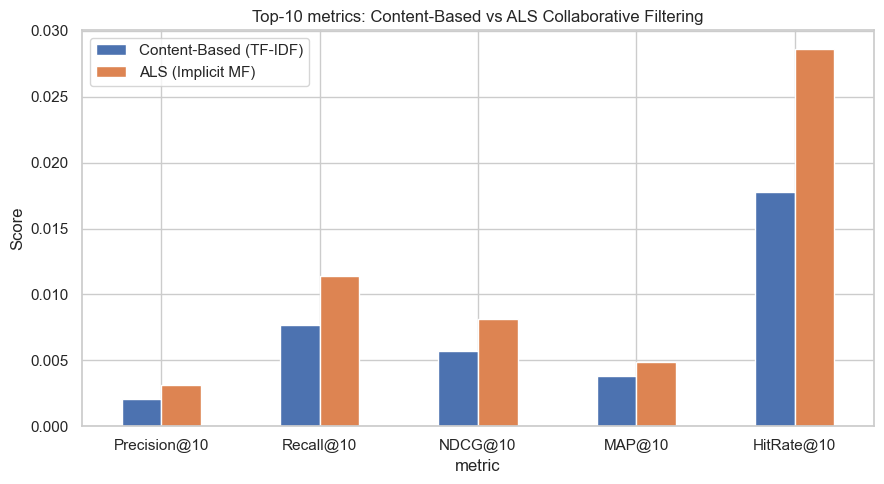

In [11]:
if cb_results_path.exists():
    fig, ax = plt.subplots(figsize=(9, 5))
    comparison[['content_based', 'als_cf']].plot(kind='bar', ax=ax, rot=0)
    ax.set_title(f'Top-{TOP_K} metrics: Content-Based vs ALS Collaborative Filtering')
    ax.set_ylabel('Score')
    ax.legend(['Content-Based (TF-IDF)', 'ALS (Implicit MF)'])
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'comparison_vs_content_based.png', dpi=150)
    plt.show()

## 9. Qualitative spot-check

In [12]:
def describe_items(item_ids, articles_df, max_show=5):
    cols = [c for c in ['prod_name', 'product_type_name', 'colour_group_name'] if c in articles_df.columns]
    valid = [i for i in item_ids if i in articles_df['article_id'].values][:max_show]
    return articles_df.set_index('article_id').loc[valid, cols]

seen = train.groupby('customer_id')['article_id'].apply(set).to_dict()
rng = np.random.default_rng(RANDOM_SEED)
spot_check_users = rng.choice(list(recommendations.keys()), size=3, replace=False)
for u in spot_check_users:
    print(f'\n=== User {u} ===')
    print('\nPurchased in train (sample):')
    print(describe_items(list(seen.get(u, set()))[:5], articles))
    print('\nALS recommended:')
    print(describe_items(recommendations[u], articles))
    print('\nActual test purchases:')
    print(describe_items(list(ground_truth.get(u, set())), articles))


=== User 8d438716c814e573bb41442ca0f26fe6e99167b77b90a791c34bd9a4e1e53160 ===

Purchased in train (sample):
           prod_name product_type_name colour_group_name
article_id                                              
0637055003      Tuss             Dress        Light Blue

ALS recommended:
                       prod_name product_type_name colour_group_name
article_id                                                          
0349301001    GLASSIG ESPADRILLE        Ballerinas             Black
0751471001   Pluto RW slacks (1)          Trousers             Black
0759465001        TILDA HIP BELT              Belt             Black
0783346001          Primo slacks          Trousers             Black
0880839001  Eleonor button dress             Dress             Black

Actual test purchases:
                                prod_name product_type_name colour_group_name
article_id                                                                   
0719655014        Greta Ch hipster ctn 

## Next steps

1. **Capture the comparison numbers.** Add a 2-paragraph write-up to `docs/findings_cf.md` covering: (a) which model wins on each metric, (b) where ALS beats content-based and where it does not, (c) what the cold-start exposure implies.
2. **Sanity-check ALS hyperparameters.** Try `factors=32` and `factors=128`; document the trade-off in `outputs/collaborative_filtering/hp_sweep.csv` (saves time during Notebook 06 cross-validation).
3. **Update `logbook.md`** with sprint progress.
4. **Move on to `04_hybrid.ipynb`** — weighted ensemble of content-based + ALS, with a popularity fallback for cold users.